In [1]:
%reload_ext autoreload
%autoreload 2

In [3]:
import csv

import evaluate
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import AutoTokenizer
from transformers import DataCollatorForTokenClassification, AutoConfig
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer

from torch import cuda


/opt/homebrew/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/homebrew/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
W0212 15:26:59.299000 15734 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [4]:
device = 'cpu'
if cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
print(device)



mps


In [5]:
data_dir = 'data_updated/'
language = 'dutch'
model_checkpoint = "models/finetuned/single/dutch/GysBERT-dutch-fold-1-train_size-1.0/"

model_name = model_checkpoint.split('/')[-1]

config = AutoConfig.from_pretrained(model_checkpoint)
labels_to_ids = config.label2id
ids_to_labels = config.id2label


metric = evaluate.load("seqeval")

## Evaluate Folds

In [393]:
from hist_smell.evaluation.near_misses import read_pred_file
from hist_smell.evaluation.near_misses import tokens_to_spans

from hist_smell.evaluation.near_misses import find_overlapping_spans
from hist_smell.evaluation.near_misses import make_overlapping_spans_dataframe
from hist_smell.evaluation.near_misses import score_strict_lenient

folds_score = []
languages = ['de', 'en', 'fr', 'it', 'nl']
languages = ['en', 'fr']
for model_type in ['historical', 'contemporary']:
    for lang in languages:
        for fold in range(0, 5):
            multi_test_file = f'test-files-mt-all-lang/out-fold-smell-{lang}/folds_{fold}_test.tsv'
            if model_type == 'historical':
                multi_pred_file = f'multitask/predictions-mt/predictions-{lang}/{fold}_prediction.tsv'
            else:
                multi_pred_file = f'multitask/predictions-mt/predictions-{lang}-contemporary/{fold}_prediction-contemporary.tsv'
            pred_tokens = list(read_pred_file(multi_pred_file))
            test_tokens = list(read_pred_file(multi_test_file))
            
            pred_spans = tokens_to_spans(pred_tokens)
            test_spans = tokens_to_spans(test_tokens)
            
            test_df = pd.DataFrame([ts.__dict__ for ts in test_spans])
            pred_df = pd.DataFrame([ps.__dict__ for ps in pred_spans])
            test_freq = test_df.label.value_counts().rename('test_freq')
            pred_freq = pred_df.label.value_counts().rename('pred_freq')
            
            overlapping_spans = find_overlapping_spans(test_spans, pred_spans)
            print(lang, fold, len(overlapping_spans), len(test_spans), len(pred_spans))
            overlap_df = make_overlapping_spans_dataframe(overlapping_spans)
            
            fold_score = score_strict_lenient(overlap_df, test_freq, pred_freq)
            fold_score['fold'] = fold
            fold_score['lang'] = lang
            fold_score['model_type'] = model_type
            folds_score.append(fold_score)
            
    
folds_score = pd.concat(folds_score)
folds_score = folds_score.reset_index().rename(columns={'index': 'ent_type'})
folds_score.sort_index()


en 0 815 607 646
en 1 1455 1119 1102
en 2 1096 868 833
en 3 1229 953 969
en 4 1282 969 1008
fr 0 252 166 143
fr 1 735 564 381
fr 2 469 376 271
fr 3 494 394 286
fr 4 627 448 406
en 0 810 607 618
en 1 1510 1119 1109
en 2 1080 868 800
en 3 1240 953 946
en 4 1242 969 934
fr 0 260 166 165
fr 1 696 564 402
fr 2 496 376 341
fr 3 622 394 468
fr 4 563 448 273


,ent_type,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1,fold,lang,model_type
0,Smell_Word,0.911243,0.890173,0.900585,0.923077,0.901734,0.912281,0,en,historical
1,Smell_Source,0.396341,0.515873,0.448276,0.530488,0.690476,0.600000,0,en,historical
2,Quality,0.785714,0.798387,0.792000,0.873016,0.887097,0.880000,0,en,historical
3,Perceiver,0.370370,0.465116,0.412371,0.518519,0.651163,0.577320,0,en,historical
4,Odour_Carrier,0.500000,0.195122,0.280702,0.625000,0.243902,0.350877,0,en,historical
...,...,...,...,...,...,...,...,...,...,...
255,Time,0.000000,0.000000,0.000000,1.000000,0.111111,0.200000,4,fr,contemporary
256,Evoked_Odorant,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4,fr,contemporary
257,Overall,0.523810,0.319196,0.396671,0.747253,0.455357,0.565881,4,fr,contemporary
258,macro_avg,0.175352,0.133733,0.167212,0.540639,0.234216,0.331453,4,fr,contemporary


## Analyse tokenisers

In [2]:
import evaluate
import numpy as np
import torch
from datasets import Dataset
from transformers import AutoTokenizer
from transformers import DataCollatorForTokenClassification, AutoConfig
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer

from torch import cuda

device = 'cpu'
if cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
print(device)



/opt/homebrew/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/homebrew/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
W0218 16:46:58.004000 32830 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


mps


In [275]:
data_dir = 'data_updated/'
language = 'dutch'
model_historic = {
    'dutch': "emanjavacas/GysBERT",
    'english': "emanjavacas/MacBERTh",
    'french': "pjox/dalembert",
    'german': "christinbeck/GHisBERT",
    'italian': "models/pretrain/it_model/bertoldo-all/checkpoint/"
}

model_contemp = {
    "english": "google-bert/bert-base-cased",
    "italian": "dbmdz/bert-base-italian-cased",
    "dutch": "GroNLP/bert-base-dutch-cased",
    "french": "flaubert/flaubert_base_cased",
    "german": "google-bert/bert-base-german-cased"
}

model_names = {
    'contemporary': model_contemp,
    'historical': model_historic
}

trained_checkpoint = 'models/finetuned/single/dutch/GysBERT-dutch-fold-1-train_size-1.0/'

config = AutoConfig.from_pretrained(trained_checkpoint)
labels_to_ids = config.label2id
ids_to_labels = config.id2label


# metric = evaluate.load("seqeval")

In [375]:
from train_single import read_split_fold, read_split_fold_multi, tokenize_and_align_labels
from collections import defaultdict

import pandas as pd

token_info = defaultdict(dict)

languages = [
    'dutch', 
    'english', 
    'french', 
    'german', 
    'italian'
]

lang_code_map = {
    'dutch': 'nl', 
    'english': 'en', 
    'french': 'fr', 
    'german': 'de', 
    'italian': 'it'
}

for model_type in model_names:
    model_checkpoint = model_names[model_type]
    
    for language in languages:

        lang_code = lang_code_map[language]
        
        if model_type == 'historical':
            add_prefix_space = True if language == 'french' else False
            max_length = 128 if language == 'italian' else 512
        
        if model_checkpoint[language] is None:
            continue
        print(f"\n-----------------\nLANGUAGE {language}\n")
        tokenizer = AutoTokenizer.from_pretrained(model_checkpoint[language], add_prefix_space=add_prefix_space)
    
        #config = AutoConfig.from_pretrained(model_checkpoint[language])
        #labels_to_ids = config.label2id
        #ids_to_labels = config.id2label
        #print(f"labels_to_ids: {labels_to_ids}")

        fold = 1
        for fold in range(0, 5):
            fold_path = f'test-files-mt-all-lang/out-fold-smell-{lang_code}/folds_{fold}_test.tsv'
            with open(fold_path, 'rt') as fh:
                for line in fh:
                    if len(line.strip('\n')) <= 1:
                        continue
                    text_id, sent_token, chars, token, *labels = line.strip('\n').split('\t')
                    sent_idx, token_idx = [int(x) for x in sent_token.split('-')]        
                    token_labels = [l for l in labels if l != 'O']
                    subtokens = tokenizer.tokenize(token)
                    if len(subtokens) == 0:
                        print([language, sent_idx, token_idx, token, token_labels, subtokens])
                        continue
                    if subtokens[-1].endswith('</w>'):
                        subtokens = [st.replace('</w>', '') for st in subtokens]
                        subtokens = [st if si == 0 else f"##{st}" for si, st in enumerate(subtokens)]
                    token_info[(model_type, fold, language, text_id, sent_idx, token_idx)] = {
                            'language': language, 'text_id': text_id, 'sent_idx': sent_idx, 'token_idx': token_idx, 
                            'token': token, 'word_label': token_labels, 'subtokens': subtokens, 'model_type': model_type, 'fold': fold
                        }
                    #print(token, label, subtokens)

            
token_df = pd.DataFrame(token_info.values())


-----------------
LANGUAGE dutch


-----------------
LANGUAGE english

['english', 14, 22, '', [''], []]
['english', 14, 26, '', [''], []]
['english', 211, 14, '', [''], []]
['english', 211, 20, '', [''], []]
['english', 222, 24, '', [''], []]
['english', 222, 28, '', [''], []]

-----------------
LANGUAGE french

['french', 1, 3, '', [''], []]
['french', 14, 37, '', [''], []]

-----------------
LANGUAGE german


-----------------
LANGUAGE italian

['italian', 34, 33, '', [], []]
['italian', 195, 6, '', [], []]
['italian', 143, 11, '', ['I-Time'], []]
['italian', 152, 13, '', [], []]
['italian', 152, 15, '', [], []]
['italian', 90, 74, '', [], []]
['italian', 124, 6, '', [], []]
['italian', 133, 13, '', [], []]
['italian', 140, 26, '', [], []]
['italian', 13, 3, '', [], []]
['italian', 26, 30, '', [], []]
['italian', 33, 7, '', [], []]
['italian', 34, 15, '', [], []]

-----------------
LANGUAGE dutch


-----------------
LANGUAGE english

['english', 14, 22, '', [''], []]
['english', 14

In [376]:
token_df.model_type.value_counts()


model_type
contemporary    1011651
historical      1011651
Name: count, dtype: int64

In [377]:
temp = token_df.groupby(['language', 'sent_idx', 'token_idx']).model_type.value_counts().unstack()
temp[temp.contemporary.isna()]

,,model_type,contemporary,historical
language,sent_idx,token_idx,,


In [378]:
token_df

,language,text_id,sent_idx,token_idx,token,word_label,subtokens,model_type,fold
0,dutch,Sanne_NL_REL_1657_Bible_Statenvertaling_sta001...,1,1,cap,[],[cap],contemporary,0
1,dutch,Sanne_NL_REL_1657_Bible_Statenvertaling_sta001...,1,2,.,[],[.],contemporary,0
2,dutch,Sanne_NL_REL_1657_Bible_Statenvertaling_sta001...,1,3,15,[],[15],contemporary,0
3,dutch,Sanne_NL_REL_1657_Bible_Statenvertaling_sta001...,1,4,.,[],[.],contemporary,0
4,dutch,Sanne_NL_REL_1657_Bible_Statenvertaling_sta001...,1,5,vers,[],[vers],contemporary,0
...,...,...,...,...,...,...,...,...,...
2023297,italian,/it_thea_1618__17__Della_Valle_Federico__La_Re...,18,29,canto,[],[canto],historical,4
2023298,italian,/it_thea_1618__17__Della_Valle_Federico__La_Re...,18,30,",",[],"[,]",historical,4
2023299,italian,/it_thea_1618__17__Della_Valle_Federico__La_Re...,18,31,i,[],[i],historical,4
2023300,italian,/it_thea_1618__17__Della_Valle_Federico__La_Re...,18,32,languidi,[],"[langui, ##di]",historical,4


In [414]:
token_df['language'] = token_df.language.apply(lambda x: lang_code_map[x])

In [379]:
token_df['num_subtokens'] = token_df.subtokens.apply(len)
token_df.num_subtokens

0          1
1          1
2          1
3          1
4          1
          ..
2023297    1
2023298    1
2023299    1
2023300    2
2023301    1
Name: num_subtokens, Length: 2023302, dtype: int64

#### Overall Subtoken Fertility Rate

In [380]:
temp = token_df.groupby(['language', 'model_type']).num_subtokens.sum() / token_df.groupby('model_type').language.value_counts()
temp.rename('SFR').reset_index()

,language,model_type,SFR
0,dutch,contemporary,1.476225
1,dutch,historical,1.226513
2,english,contemporary,1.225318
3,english,historical,1.131489
4,french,contemporary,1.211880
5,french,historical,1.270356
6,german,contemporary,1.285935
7,german,historical,1.839895
8,italian,contemporary,1.249488
9,italian,historical,1.150754


#### Subtoken Fertility Rate per Entity Type

In [381]:
token_df['ent_types'] = token_df.word_label.apply(lambda labels: [x[2:] if '-' in x else x for x in labels])

In [415]:
token_df.explode('ent_types').groupby(['language', 'fold']).ent_types.value_counts().unstack()

ent_types               Circumstances  Effect  Evoked_Odorant  Location  \
language fold                                                             
de       0         NaN          568.0   798.0           162.0     336.0   
         1         NaN          760.0  1014.0           238.0     242.0   
         2         NaN          420.0   508.0           204.0     178.0   
         3         NaN         1006.0   622.0           338.0     266.0   
         4         NaN          662.0   898.0           330.0     224.0   
en       0     48284.0          540.0   466.0            90.0     356.0   
         1     54934.0          486.0  1052.0            96.0     588.0   
         2     43088.0          612.0   328.0            70.0     378.0   
         3     49016.0          770.0   496.0           250.0     440.0   
         4     41170.0          538.0   480.0           228.0     392.0   
fr       0     24844.0          158.0    40.0             2.0     202.0   
         1     12490.0          256.0   122.0            70.0     134.0   
         2     12872.0          162.0    46.0            18.0      96.0   
         3     13394.0          168.0    76.0            50.0     108.0   
         4     18758.0          180.0   144.0            44.0     142.0   
it       0         NaN          290.0   116.0           114.0     188.0   
         1         NaN          720.0   530.0           168.0     258.0   
         2         NaN          698.0   256.0           140.0     118.0   
         3         NaN          526.0   368.0            78.0     188.0   
         4         NaN          678.0   296.0           198.0     262.0   
nl       0         NaN         1076.0   654.0           320.0     412.0   
         1         NaN         1420.0   884.0           254.0     356.0   
         2         NaN         1242.0   682.0           400.0     358.0   
         3         NaN         1240.0  1042.0           354.0     322.0   
         4         NaN         1328.0   854.0           328.0     288.0   

ent_types      Odour_Carrier  Perceiver  Quality  Smell_Source  Smell_Word  \
language fold                                                                
de       0              70.0      114.0    548.0        1056.0       614.0   
         1             118.0      130.0    572.0         974.0       636.0   
         2              32.0      266.0    558.0        1258.0       632.0   
         3             110.0      144.0    562.0        1114.0       640.0   
         4              48.0      204.0    586.0        1158.0       636.0   
en       0             236.0      168.0    392.0         730.0       374.0   
         1             188.0      420.0    650.0        1360.0       708.0   
         2             228.0      270.0    538.0        1148.0       556.0   
         3             224.0      320.0    588.0        1350.0       608.0   
         4             216.0      246.0    512.0        1348.0       594.0   
fr       0              32.0       40.0     78.0         192.0        74.0   
         1              82.0      124.0    246.0         646.0       304.0   
         2              52.0       64.0    218.0         326.0       240.0   
         3              28.0       52.0    192.0         398.0       268.0   
         4              74.0      130.0    212.0         394.0       268.0   
it       0             110.0       64.0    250.0         610.0       304.0   
         1             186.0      140.0    452.0        1272.0       614.0   
         2             172.0       58.0    324.0         920.0       496.0   
         3             158.0       56.0    266.0         704.0       438.0   
         4             152.0      126.0    318.0         922.0       482.0   
nl       0             292.0      172.0    366.0        1574.0       686.0   
         1             252.0      202.0    334.0        1486.0       690.0   
         2             260.0      218.0    398.0        1412.0       690.0   
         3             3

In [416]:
token_df.explode('word_label').groupby(['language', 'word_label', 'model_type']).num_subtokens.describe()

count      mean       std  min  25%  \
language word_label       model_type                                           
de       B-Circumstances  contemporary   202.0  1.257426  0.558132  1.0  1.0   
                          historical     202.0  1.861386  1.017554  1.0  1.0   
         B-Effect         contemporary   294.0  1.326531  0.687909  1.0  1.0   
                          historical     294.0  1.836735  1.035485  1.0  1.0   
         B-Evoked_Odorant contemporary   211.0  1.526066  1.015608  1.0  1.0   
...                                        ...       ...       ...  ...  ...   
nl       I-Smell_Source   historical    1884.0  1.530786  0.854594  1.0  1.0   
         I-Smell_Word     contemporary    33.0  1.393939  0.966288  1.0  1.0   
                          historical      33.0  1.393939  0.704423  1.0  1.0   
         I-Time           contemporary   276.0  1.532609  0.915933  1.0  1.0   
                          historical     276.0  1.195652  0.550817  1.0  1.0   

                                        50%  75%  max  
language word_label       model_type                   
de       B-Circumstances  contemporary  1.0  1.0  4.0  
                          historical    2.0  2.0  6.0  
         B-Effect         contemporary  1.0  1.0  4.0  
                          historical    2.0  2.0  6.0  
         B-Evoked_Odorant contemporary  1.0  2.0  6.0  
...                                     ...  ...  ...  
nl       I-Smell_Source   historical    1.0  2.0  6.0  
         I-Smell_Word     contemporary  1.0  1.0  5.0  
                          historical    1.0  2.0  3.0  
         I-Time           contemporary  1.0  2.0  5.0  
                          historical    1.0  1.0  4.0  

[204 rows x 8 columns]

Descriptive SFR statistics across folds:

In [526]:
sfr_ent = token_df.explode('ent_types').rename(columns={'ent_types': 'ent_type'}).groupby(['language', 'ent_type', 'model_type']).num_subtokens.describe()


In [527]:
sfr_ent.loc['de']

count      mean       std  min  25%  50%  75%  \
ent_type       model_type                                                     
Circumstances  contemporary  1708.0  1.289227  0.649961  1.0  1.0  1.0  1.0   
               historical    1708.0  1.911007  1.216098  1.0  1.0  2.0  2.0   
Effect         contemporary  1920.0  1.334375  0.722356  1.0  1.0  1.0  1.0   
               historical    1920.0  1.916146  1.178560  1.0  1.0  2.0  2.0   
Evoked_Odorant contemporary   636.0  1.517296  0.919440  1.0  1.0  1.0  2.0   
               historical     636.0  2.116352  1.414987  1.0  1.0  2.0  3.0   
Location       contemporary   623.0  1.359551  0.691544  1.0  1.0  1.0  2.0   
               historical     623.0  1.770465  1.079014  1.0  1.0  1.0  2.0   
Odour_Carrier  contemporary   189.0  1.492063  0.796395  1.0  1.0  1.0  2.0   
               historical     189.0  2.005291  1.310747  1.0  1.0  2.0  3.0   
Perceiver      contemporary   429.0  1.286713  0.686543  1.0  1.0  1.0  1.0   
               historical     429.0  1.827506  1.153252  1.0  1.0  1.0  2.0   
Quality        contemporary  1413.0  1.429582  0.728927  1.0  1.0  1.0  2.0   
               historical    1413.0  2.426752  1.229267  1.0  1.0  2.0  3.0   
Smell_Source   contemporary  2780.0  1.539209  0.901146  1.0  1.0  1.0  2.0   
               historical    2780.0  2.248561  1.406974  1.0  1.0  2.0  3.0   
Smell_Word     contemporary  1579.0  2.177961  0.809087  1.0  2.0  2.0  3.0   
               historical    1579.0  2.625712  1.300725  1.0  2.0  2.0  3.0   
Time           contemporary   372.0  1.311828  0.672582  1.0  1.0  1.0  1.0   
               historical     372.0  1.806452  1.043610  1.0  1.0  2.0  2.0   

                              max  
ent_type       model_type          
Circumstances  contemporary   5.0  
               historical     9.0  
Effect         contemporary   7.0  
               historical     9.0  
Evoked_Odorant contemporary   6.0  
               historical     9.0  
Location       contemporary   5.0  
               historical     7.0  
Odour_Carrier  contemporary   5.0  
               historical     8.0  
Perceiver      contemporary   5.0  
               historical     8.0  
Quality        contemporary   5.0  
               historical     8.0  
Smell_Source   contemporary   8.0  
               historical    10.0  
Smell_Word     contemporary   7.0  
               historical     8.0  
Time           contemporary   5.0  
               historical     7.0

In [528]:
sfr_ent.loc['en']

count      mean       std  min  25%  50%  75%  \
ent_type       model_type                                                       
               contemporary  118246.0  1.225318  0.661794  1.0  1.0  1.0  1.0   
               historical    118246.0  1.131489  0.468642  1.0  1.0  1.0  1.0   
Circumstances  contemporary    1473.0  1.243041  0.702766  1.0  1.0  1.0  1.0   
               historical      1473.0  1.170401  0.553048  1.0  1.0  1.0  1.0   
Effect         contemporary    1411.0  1.309709  0.754963  1.0  1.0  1.0  1.0   
               historical      1411.0  1.144578  0.458572  1.0  1.0  1.0  1.0   
Evoked_Odorant contemporary     367.0  1.452316  0.888474  1.0  1.0  1.0  1.0   
               historical       367.0  1.329700  0.755863  1.0  1.0  1.0  1.0   
Location       contemporary    1077.0  1.201486  0.593707  1.0  1.0  1.0  1.0   
               historical      1077.0  1.171773  0.513047  1.0  1.0  1.0  1.0   
Odour_Carrier  contemporary     546.0  1.430403  0.871417  1.0  1.0  1.0  1.0   
               historical       546.0  1.217949  0.556964  1.0  1.0  1.0  1.0   
Perceiver      contemporary     712.0  1.259831  0.776710  1.0  1.0  1.0  1.0   
               historical       712.0  1.171348  0.539698  1.0  1.0  1.0  1.0   
Quality        contemporary    1340.0  1.685075  0.981951  1.0  1.0  1.0  2.0   
               historical      1340.0  1.395522  0.700140  1.0  1.0  1.0  2.0   
Smell_Source   contemporary    2968.0  1.708558  1.125568  1.0  1.0  1.0  2.0   
               historical      2968.0  1.463949  0.852076  1.0  1.0  1.0  2.0   
Smell_Word     contemporary    1420.0  2.138732  1.070348  1.0  1.0  2.0  3.0   
               historical      1420.0  1.538028  0.751295  1.0  1.0  1.0  2.0   
Time           contemporary     386.0  1.093264  0.396879  1.0  1.0  1.0  1.0   
               historical       386.0  1.095855  0.379519  1.0  1.0  1.0  1.0   

                             max  
ent_type       model_type         
               contemporary  9.0  
               historical    9.0  
Circumstances  contemporary  6.0  
               historical    5.0  
Effect         contemporary  6.0  
               historical    5.0  
Evoked_Odorant contemporary  5.0  
               historical    5.0  
Location       contemporary  5.0  
               historical    5.0  
Odour_Carrier  contemporary  6.0  
               historical    4.0  
Perceiver      contemporary  7.0  
               historical    6.0  
Quality        contemporary  6.0  
               historical    5.0  
Smell_Source   contemporary  9.0  
               historical    6.0  
Smell_Word     contemporary  6.0  
               historical    5.0  
Time           contemporary  3.0  
               historical    3.0

In [529]:
sfr_ent.loc['fr']

count      mean       std  min  25%  50%  75%  \
ent_type       model_type                                                      
               contemporary  41179.0  1.211880  0.560237  1.0  1.0  1.0  1.0   
               historical    41179.0  1.270356  0.707487  1.0  1.0  1.0  1.0   
Circumstances  contemporary    462.0  1.222944  0.547201  1.0  1.0  1.0  1.0   
               historical      462.0  1.296537  0.691401  1.0  1.0  1.0  1.0   
Effect         contemporary    214.0  1.252336  0.566572  1.0  1.0  1.0  1.0   
               historical      214.0  1.285047  0.603636  1.0  1.0  1.0  1.0   
Evoked_Odorant contemporary     92.0  1.565217  0.802528  1.0  1.0  1.0  2.0   
               historical       92.0  1.728261  1.080326  1.0  1.0  1.0  2.0   
Location       contemporary    341.0  1.246334  0.644679  1.0  1.0  1.0  1.0   
               historical      341.0  1.381232  0.871847  1.0  1.0  1.0  1.0   
Odour_Carrier  contemporary    134.0  1.365672  0.619739  1.0  1.0  1.0  2.0   
               historical      134.0  1.529851  0.828898  1.0  1.0  1.0  2.0   
Perceiver      contemporary    205.0  1.380488  0.852683  1.0  1.0  1.0  1.0   
               historical      205.0  1.439024  0.940608  1.0  1.0  1.0  1.0   
Quality        contemporary    473.0  1.452431  0.785434  1.0  1.0  1.0  2.0   
               historical      473.0  1.458774  0.812307  1.0  1.0  1.0  2.0   
Smell_Source   contemporary    978.0  1.566462  0.840493  1.0  1.0  1.0  2.0   
               historical      978.0  1.723926  1.054046  1.0  1.0  1.0  2.0   
Smell_Word     contemporary    577.0  1.580589  0.823381  1.0  1.0  1.0  2.0   
               historical      577.0  1.698440  0.938683  1.0  1.0  1.0  2.0   
Time           contemporary    169.0  1.165680  0.508036  1.0  1.0  1.0  1.0   
               historical      169.0  1.230769  0.663684  1.0  1.0  1.0  1.0   

                              max  
ent_type       model_type          
               contemporary   8.0  
               historical    10.0  
Circumstances  contemporary   4.0  
               historical     5.0  
Effect         contemporary   4.0  
               historical     3.0  
Evoked_Odorant contemporary   5.0  
               historical     5.0  
Location       contemporary   6.0  
               historical     7.0  
Odour_Carrier  contemporary   4.0  
               historical     4.0  
Perceiver      contemporary   8.0  
               historical     7.0  
Quality        contemporary   5.0  
               historical     5.0  
Smell_Source   contemporary   6.0  
               historical     8.0  
Smell_Word     contemporary   5.0  
               historical     5.0  
Time           contemporary   4.0  
               historical     5.0

In [530]:
sfr_ent.loc['it']

count      mean       std  min  25%  50%  75%  \
ent_type       model_type                                                     
Circumstances  contemporary  1456.0  1.259615  0.597742  1.0  1.0  1.0  1.0   
               historical    1456.0  1.189560  0.508134  1.0  1.0  1.0  1.0   
Effect         contemporary   783.0  1.274585  0.604717  1.0  1.0  1.0  1.0   
               historical     783.0  1.163474  0.470451  1.0  1.0  1.0  1.0   
Evoked_Odorant contemporary   349.0  1.300860  0.646409  1.0  1.0  1.0  1.0   
               historical     349.0  1.200573  0.530560  1.0  1.0  1.0  1.0   
Location       contemporary   507.0  1.284024  0.745342  1.0  1.0  1.0  1.0   
               historical     507.0  1.216963  0.688893  1.0  1.0  1.0  1.0   
Odour_Carrier  contemporary   389.0  1.311054  0.716813  1.0  1.0  1.0  1.0   
               historical     389.0  1.192802  0.552734  1.0  1.0  1.0  1.0   
Perceiver      contemporary   222.0  1.256757  0.587829  1.0  1.0  1.0  1.0   
               historical     222.0  1.126126  0.406221  1.0  1.0  1.0  1.0   
Quality        contemporary   805.0  1.843478  0.911697  1.0  1.0  2.0  3.0   
               historical     805.0  1.568944  0.717083  1.0  1.0  1.0  2.0   
Smell_Source   contemporary  2214.0  1.481030  0.838172  1.0  1.0  1.0  2.0   
               historical    2214.0  1.353659  0.751587  1.0  1.0  1.0  1.0   
Smell_Word     contemporary  1167.0  1.885176  0.842998  1.0  1.0  2.0  2.0   
               historical    1167.0  1.551842  0.706872  1.0  1.0  1.0  2.0   
Time           contemporary   381.0  1.086614  0.377463  1.0  1.0  1.0  1.0   
               historical     381.0  1.031496  0.249326  1.0  1.0  1.0  1.0   

                              max  
ent_type       model_type          
Circumstances  contemporary   5.0  
               historical     4.0  
Effect         contemporary   4.0  
               historical     4.0  
Evoked_Odorant contemporary   5.0  
               historical     4.0  
Location       contemporary  10.0  
               historical    10.0  
Odour_Carrier  contemporary   8.0  
               historical     6.0  
Perceiver      contemporary   4.0  
               historical     4.0  
Quality        contemporary   5.0  
               historical     5.0  
Smell_Source   contemporary   7.0  
               historical     7.0  
Smell_Word     contemporary   5.0  
               historical     5.0  
Time           contemporary   5.0  
               historical     5.0

In [531]:
sfr_ent.loc['nl']

count      mean       std  min  25%  50%  75%  \
ent_type       model_type                                                     
Circumstances  contemporary  3153.0  1.464003  0.904403  1.0  1.0  1.0  2.0   
               historical    3153.0  1.218522  0.570098  1.0  1.0  1.0  1.0   
Effect         contemporary  2058.0  1.531584  0.930875  1.0  1.0  1.0  2.0   
               historical    2058.0  1.231293  0.587466  1.0  1.0  1.0  1.0   
Evoked_Odorant contemporary   828.0  1.804348  1.235462  1.0  1.0  1.0  2.0   
               historical     828.0  1.478261  0.857860  1.0  1.0  1.0  2.0   
Location       contemporary   868.0  1.512673  0.888774  1.0  1.0  1.0  2.0   
               historical     868.0  1.259217  0.639597  1.0  1.0  1.0  1.0   
Odour_Carrier  contemporary   701.0  1.997147  1.205934  1.0  1.0  2.0  3.0   
               historical     701.0  1.574893  0.952679  1.0  1.0  1.0  2.0   
Perceiver      contemporary   509.0  1.626719  0.833686  1.0  1.0  1.0  2.0   
               historical     509.0  1.255403  0.622412  1.0  1.0  1.0  1.0   
Quality        contemporary   954.0  2.097484  1.240254  1.0  1.0  2.0  3.0   
               historical     954.0  1.733753  0.900258  1.0  1.0  1.0  2.0   
Smell_Source   contemporary  3705.0  1.972740  1.233995  1.0  1.0  2.0  3.0   
               historical    3705.0  1.573549  0.929219  1.0  1.0  1.0  2.0   
Smell_Word     contemporary  1725.0  2.013333  1.193732  1.0  1.0  2.0  3.0   
               historical    1725.0  1.939130  0.954477  1.0  1.0  2.0  2.0   
Time           contemporary   393.0  1.569975  0.979803  1.0  1.0  1.0  2.0   
               historical     393.0  1.213740  0.567050  1.0  1.0  1.0  1.0   

                             max  
ent_type       model_type         
Circumstances  contemporary  7.0  
               historical    6.0  
Effect         contemporary  9.0  
               historical    8.0  
Evoked_Odorant contemporary  9.0  
               historical    7.0  
Location       contemporary  7.0  
               historical    7.0  
Odour_Carrier  contemporary  7.0  
               historical    5.0  
Perceiver      contemporary  5.0  
               historical    5.0  
Quality        contemporary  7.0  
               historical    7.0  
Smell_Source   contemporary  9.0  
               historical    6.0  
Smell_Word     contemporary  9.0  
               historical    6.0  
Time           contemporary  6.0  
               historical    4.0

#### Correlation between SFR and F_1

In [471]:
folds_score[['lenient_f1', 'exact_f1', 'fold', 'lang', 'model_type']]
f1_score = (folds_score[folds_score.ent_type.isin(['Overall', 'macro_avg', 'weight_avg']) == False]
    .rename(columns={'lang': 'language'})
    .pivot(index=['fold', 'language', 'ent_type'], values='exact_f1', columns='model_type'))
f1_diff = (f1_score.contemporary - f1_score.historical).rename('exact_f1')
f1_diff

fold  language  ent_type      
0     en        Circumstances    -0.074401
                Effect           -0.007353
                Evoked_Odorant   -0.062201
                Location          0.146604
                Odour_Carrier    -0.058480
                                    ...   
4     fr        Perceiver        -0.041667
                Quality          -0.153563
                Smell_Source     -0.142709
                Smell_Word       -0.110289
                Time             -0.125000
Name: exact_f1, Length: 100, dtype: float64

In [467]:
sfr_ent = sfr_ent.swaplevel(0, 2).drop(['']).swaplevel(0, 2)

/var/folders/xk/pp9n20396sqccydf42gn2rmr0000gn/T/ipykernel_32830/1022843430.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  sfr_ent = sfr_ent.swaplevel(0, 2).drop(['']).swaplevel(0, 2)


In [473]:
sfr_score = sfr_ent.reset_index().pivot(index=['fold', 'language', 'ent_type'], values='mean', columns='model_type')
sfr_diff = (sfr_score.contemporary - sfr_score.historical).rename('mean_sfr')
sfr_diff = sfr_diff.swaplevel(0, 1).loc[['en', 'fr']].swaplevel(0, 1)

In [489]:
f1_diff.swaplevel(0, 2).swaplevel(0, 1).loc['en'].sort_values()

ent_type        fold
Time            0      -0.309524
Evoked_Odorant  2      -0.190476
Effect          2      -0.172794
Location        1      -0.133536
Odour_Carrier   1      -0.126979
Time            3      -0.112407
Perceiver       4      -0.085317
Location        4      -0.082394
Smell_Source    1      -0.079461
Quality         0      -0.077171
Circumstances   0      -0.074401
Perceiver       3      -0.072239
Quality         1      -0.071113
Circumstances   1      -0.070996
Odour_Carrier   4      -0.069576
Smell_Source    2      -0.067680
                3      -0.063255
Evoked_Odorant  0      -0.062201
Odour_Carrier   0      -0.058480
Location        2      -0.054080
Perceiver       1      -0.044657
Effect          1      -0.042494
Quality         4      -0.041995
Smell_Source    0      -0.036291
                4      -0.031785
Circumstances   2      -0.027826
Effect          4      -0.027778
Smell_Word      3      -0.024316
Evoked_Odorant  3      -0.021739
Quality         3     

In [493]:
f1_score.reset_index().groupby(['language', 'ent_type'])[['contemporary', 'historical']].mean()

model_type               contemporary  historical
language ent_type                                
en       Circumstances       0.310821    0.320728
         Effect              0.155338    0.203612
         Evoked_Odorant      0.312391    0.366512
         Location            0.422897    0.438565
         Odour_Carrier       0.329265    0.374582
         Perceiver           0.412029    0.447803
         Quality             0.684409    0.729014
         Smell_Source        0.464727    0.520422
         Smell_Word          0.871306    0.886107
         Time                0.415794    0.473175
fr       Circumstances       0.040757    0.023810
         Effect              0.000000    0.000000
         Evoked_Odorant      0.397074    0.166667
         Location            0.174428    0.142706
         Odour_Carrier       0.252632    0.197211
         Perceiver           0.083744    0.077667
         Quality             0.415454    0.410214
         Smell_Source        0.329078    0.273731
         Smell_Word          0.801054    0.792273
         Time                0.120000    0.144345

In [494]:
f1_score.reset_index().groupby(['language', 'ent_type'])[['contemporary', 'historical']].std()

model_type               contemporary  historical
language ent_type                                
en       Circumstances       0.084433    0.086497
         Effect              0.073609    0.057291
         Evoked_Odorant      0.165404    0.127523
         Location            0.032052    0.105429
         Odour_Carrier       0.124898    0.084009
         Perceiver           0.056859    0.089908
         Quality             0.042169    0.041301
         Smell_Source        0.060948    0.060048
         Smell_Word          0.019665    0.014628
         Time                0.129658    0.104677
fr       Circumstances       0.038608    0.047619
         Effect              0.000000    0.000000
         Evoked_Odorant      0.399945    0.212762
         Location            0.151977    0.056912
         Odour_Carrier       0.167915    0.064230
         Perceiver           0.090513    0.023173
         Quality             0.105470    0.186382
         Smell_Source        0.168606    0.066540
         Smell_Word          0.044803    0.050326
         Time                0.178885    0.117889

In [480]:
pd.concat([sfr_diff, f1_diff], axis=1).reset_index().groupby(['language', 'ent_type'])[['mean_sfr', 'exact_f1']].corr()

mean_sfr  exact_f1
language ent_type                                   
en       Circumstances  mean_sfr  1.000000  0.294460
                        exact_f1  0.294460  1.000000
         Effect         mean_sfr  1.000000  0.385181
                        exact_f1  0.385181  1.000000
         Evoked_Odorant mean_sfr  1.000000  0.562069
                        exact_f1  0.562069  1.000000
         Location       mean_sfr  1.000000  0.110317
                        exact_f1  0.110317  1.000000
         Odour_Carrier  mean_sfr  1.000000 -0.571215
                        exact_f1 -0.571215  1.000000
         Perceiver      mean_sfr  1.000000 -0.248363
                        exact_f1 -0.248363  1.000000
         Quality        mean_sfr  1.000000 -0.509107
                        exact_f1 -0.509107  1.000000
         Smell_Source   mean_sfr  1.000000  0.674714
                        exact_f1  0.674714  1.000000
         Smell_Word     mean_sfr  1.000000  0.137205
                        exact_f1  0.137205  1.000000
         Time           mean_sfr  1.000000  0.746432
                        exact_f1  0.746432  1.000000
fr       Circumstances  mean_sfr  1.000000 -0.068120
                        exact_f1 -0.068120  1.000000
         Effect         mean_sfr  1.000000       NaN
                        exact_f1       NaN       NaN
         Evoked_Odorant mean_sfr  1.000000  0.448231
                        exact_f1  0.448231  1.000000
         Location       mean_sfr  1.000000 -0.243987
                        exact_f1 -0.243987  1.000000
         Odour_Carrier  mean_sfr  1.000000 -0.551056
                        exact_f1 -0.551056  1.000000
         Perceiver      mean_sfr  1.000000  0.417084
                        exact_f1  0.417084  1.000000
         Quality        mean_sfr  1.000000  0.350305
                        exact_f1  0.350305  1.000000
         Smell_Source   mean_sfr  1.000000  0.854384
                        exact_f1  0.854384  1.000000
         Smell_Word     mean_sfr  1.000000  0.205490
                        exact_f1  0.205490  1.000000
         Time           mean_sfr  1.000000  0.284769
                        exact_f1  0.284769  1.000000

Hmm, this is all over the place. No clear pattern, so either confounding factors, or SFR is just not a useful indicator.

In [179]:
overlap_df[overlap_df.match_type == 'partial']

,test_text_id,test_sent_idx,test_start,test_end,test_text,test_label,pred_text_id,pred_sent_idx,pred_start,pred_end,pred_text,pred_label,match_type,overlap_start,overlap_end,test_tokens,pred_tokens,overlap_tokens
24,/001E/annotation.tsv,30.0,3.0,5.0,the fruit,Smell_Source,/001E/annotation.tsv,30.0,4.0,5.0,fruit,Smell_Source,partial,late,exact,2.0,1.0,1.0
29,/001E/annotation.tsv,33.0,45.0,47.0,autumn Clematis,Smell_Source,/001E/annotation.tsv,33.0,45.0,46.0,autumn,Smell_Source,partial,exact,early,2.0,1.0,1.0
30,/001E/annotation.tsv,33.0,45.0,47.0,autumn Clematis,Smell_Source,/001E/annotation.tsv,33.0,46.0,47.0,Clematis,Smell_Source,partial,late,exact,2.0,1.0,1.0
45,/003E/annotation.tsv,116.0,29.0,31.0,with Primroses,Smell_Source,/003E/annotation.tsv,116.0,30.0,31.0,Primroses,Smell_Source,partial,late,exact,2.0,1.0,1.0
50,/003E/annotation.tsv,116.0,22.0,25.0,in cold weather,Circumstances,/003E/annotation.tsv,116.0,22.0,23.0,in,Circumstances,partial,exact,early,3.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,/072E/annotation.tsv,46.0,9.0,10.0,dung,Smell_Source,/072E/annotation.tsv,46.0,7.0,10.0,hot reeking dung,Smell_Source,partial,early,exact,1.0,3.0,1.0
783,/072E/annotation.tsv,46.0,23.0,25.0,odious to,Quality,/072E/annotation.tsv,46.0,22.0,23.0,so,Quality,partial,early,early,2.0,1.0,0.0
784,/072E/annotation.tsv,46.0,23.0,25.0,odious to,Quality,/072E/annotation.tsv,46.0,23.0,24.0,odious,Quality,partial,exact,early,2.0,1.0,1.0
814,/082E/annotation.tsv,35.0,5.0,7.0,of smelling-salts,Smell_Source,/082E/annotation.tsv,35.0,6.0,7.0,smelling-salts,Smell_Source,partial,late,exact,2.0,1.0,1.0


In [9]:
overlap_df.test_label.value_counts()

NameError: name 'overlap_df' is not defined

In [10]:
exact_label_freq = overlap_df[overlap_df.match_type == 'exact'].test_label.value_counts().rename('exact_freq')

partial_label_freq = overlap_df[overlap_df.match_type == 'partial'].test_label.value_counts().rename('partial_freq')

match_df = pd.concat([test_freq, pred_freq, exact_label_freq, partial_label_freq], axis=1).fillna(0.0)
match_df['missing'] = match_df.apply(lambda row: row['test_freq'] - row['exact_freq'] - row['partial_freq'], axis=1)
match_df['lenient_freq'] = match_df.exact_freq + match_df.partial_freq
match_df['exact_prop'] = match_df.exact_freq / match_df.exact_freq.sum()
match_df['partial_prop'] = match_df.partial_freq / match_df.partial_freq.sum()
match_df['lenient_prop'] = match_df.lenient_freq / match_df.lenient_freq.sum()

match_df.loc['Overall'] = match_df.sum()
match_df['exact_frac'] = match_df.exact_freq / match_df.test_freq
match_df['partial_frac'] = match_df.partial_freq / match_df.test_freq
match_df

NameError: name 'overlap_df' is not defined

In [11]:
def compute_f1(row, eval_type):
    prec_col = f"{eval_type}_prec"
    rec_col = f"{eval_type}_rec"
    f1_col = f"{eval_type}_f1"
    if row[prec_col] + row[rec_col] == 0.0:
        return 0.0
    else:
        return 2 * row[prec_col] * row[rec_col] / (row[prec_col] + row[rec_col])
    

match_df['exact_prec'] = match_df.exact_freq / match_df.pred_freq
match_df['exact_rec'] = match_df.exact_freq / match_df.test_freq
match_df['exact_f1'] = match_df.apply(lambda row: compute_f1(row, 'exact'), axis=1)
match_df['lenient_prec'] = match_df.lenient_freq / match_df.pred_freq
match_df['lenient_rec'] = match_df.lenient_freq / match_df.test_freq
match_df['lenient_f1'] = match_df.apply(lambda row: compute_f1(row, 'lenient'), axis=1)
match_df

NameError: name 'match_df' is not defined

In [12]:
weighted_avg_exact = (match_df[['exact_prec', 'exact_rec', 'exact_f1']].T.drop('Overall', axis=1) * match_df.drop('Overall').exact_prop).T.sum()
weighted_avg_lenient = (match_df[['lenient_prec', 'lenient_rec', 'lenient_f1']].T.drop('Overall', axis=1) * match_df.drop('Overall').lenient_prop).T.sum()
weighted_avg = pd.concat([weighted_avg_exact, weighted_avg_lenient]).rename('weight_avg')
weighted_avg

NameError: name 'match_df' is not defined

In [13]:
eval_cols = ['exact_prec', 'exact_rec', 'exact_f1', 'lenient_prec', 'lenient_rec', 'lenient_f1']
macro_avg = match_df.drop('Overall')[eval_cols].mean().rename('macro_avg')
macro_avg

NameError: name 'match_df' is not defined

In [14]:
eval_avg = pd.concat([macro_avg, weighted_avg], axis=1).T

NameError: name 'macro_avg' is not defined

In [15]:
pd.concat([match_df[eval_cols], eval_avg])


NameError: name 'match_df' is not defined

## Evaluation - Averaging over folds

In [146]:
%reload_ext autoreload
%autoreload 2



In [147]:
import pandas as pd

from hist_smell.evaluation.near_misses import read_pred_file
from hist_smell.evaluation.near_misses import tokens_to_spans

from hist_smell.evaluation.near_misses import find_overlapping_spans
from hist_smell.evaluation.near_misses import make_overlapping_spans_dataframe
from hist_smell.evaluation.near_misses import score_strict_lenient


In [18]:
multi_test_file = 'test-files-mt-all-lang/out-fold-smell-en/folds_2_test.tsv'
multi_pred_file = 'multitask/predictions-mt/predictions-en/2_prediction.tsv'
pred_tokens = list(read_pred_file(multi_pred_file))
test_tokens = list(read_pred_file(multi_test_file))

pred_spans = tokens_to_spans(pred_tokens)
test_spans = tokens_to_spans(test_tokens)

test_df = pd.DataFrame([ts.__dict__ for ts in test_spans])
pred_df = pd.DataFrame([ps.__dict__ for ps in pred_spans])
test_freq = test_df.label.value_counts().rename('test_freq')
pred_freq = pred_df.label.value_counts().rename('pred_freq')

overlapping_spans = find_overlapping_spans(test_spans, pred_spans)
print(len(overlapping_spans), len(test_spans), len(pred_spans))
overlap_df = make_overlapping_spans_dataframe(overlapping_spans)


fold_score = score_strict_lenient(overlap_df, test_freq, pred_freq)
fold_score

1096 868 833


,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1
Smell_Word,0.927039,0.874494,0.900000,0.931330,0.878543,0.904167
Smell_Source,0.507317,0.460177,0.482599,0.634146,0.575221,0.603248
Quality,0.735135,0.751381,0.743169,0.843243,0.861878,0.852459
Perceiver,0.327586,0.327586,0.327586,0.465517,0.465517,0.465517
Odour_Carrier,0.522727,0.479167,0.500000,0.636364,0.583333,0.608696
Circumstances,0.342857,0.352941,0.347826,0.628571,0.647059,0.637681
Location,0.428571,0.454545,0.441176,0.600000,0.636364,0.617647
Time,0.500000,0.368421,0.424242,0.714286,0.526316,0.606061
Effect,0.210526,0.266667,0.235294,0.315789,0.400000,0.352941
Evoked_Odorant,0.400000,0.285714,0.333333,0.600000,0.428571,0.500000


In [258]:
import pandas as pd

from hist_smell.evaluation.near_misses import read_pred_file
from hist_smell.evaluation.near_misses import tokens_to_spans

from hist_smell.evaluation.near_misses import find_overlapping_spans
from hist_smell.evaluation.near_misses import make_overlapping_spans_dataframe
from hist_smell.evaluation.near_misses import score_strict_lenient

folds_score = []
languages = ['de', 'en', 'fr', 'it', 'nl']
for lang in languages:
    for fold in range(0, 5):
        multi_test_file = f'test-files-mt-all-lang/out-fold-smell-{lang}/folds_{fold}_test.tsv'
        multi_pred_file = f'multitask/predictions-mt/predictions-{lang}/{fold}_prediction.tsv'
        pred_tokens = list(read_pred_file(multi_pred_file))
        test_tokens = list(read_pred_file(multi_test_file))
        
        pred_spans = tokens_to_spans(pred_tokens)
        test_spans = tokens_to_spans(test_tokens)
        
        test_df = pd.DataFrame([ts.__dict__ for ts in test_spans])
        pred_df = pd.DataFrame([ps.__dict__ for ps in pred_spans])
        test_freq = test_df.label.value_counts().rename('test_freq')
        pred_freq = pred_df.label.value_counts().rename('pred_freq')
        
        overlapping_spans = find_overlapping_spans(test_spans, pred_spans)
        print(lang, fold, len(overlapping_spans), len(test_spans), len(pred_spans))
        overlap_df = make_overlapping_spans_dataframe(overlapping_spans)
        
        fold_score = score_strict_lenient(overlap_df, test_freq, pred_freq)
        fold_score['fold'] = fold
        fold_score['lang'] = lang
        folds_score.append(fold_score)

folds_score = pd.concat(folds_score)
folds_score = folds_score.reset_index().rename(columns={'index': 'ent_type'})
folds_score.sort_index()


de 0 1256 973 847
de 1 1277 1037 754
de 2 1525 1023 1108
de 3 1241 1055 751
de 4 1262 1027 774
en 0 815 607 646
en 1 1455 1119 1102
en 2 1096 868 833
en 3 1229 953 969
en 4 1282 969 1008
fr 0 252 166 143
fr 1 735 564 381
fr 2 469 376 271
fr 3 494 394 286
fr 4 627 448 406
it 0 526 427 347
it 1 1093 836 730
it 2 802 670 517
it 3 693 570 446
it 4 766 647 492
nl 0 1699 1205 1135
nl 1 1584 1219 1034
nl 2 1665 1232 1084
nl 3 1655 1255 1115
nl 4 1703 1287 1054


,ent_type,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1,fold,lang
0,Smell_Word,0.860806,0.848375,0.854545,0.875458,0.862816,0.869091,0,de
1,Smell_Source,0.444915,0.394737,0.418327,0.601695,0.533835,0.565737,0,de
2,Quality,0.575581,0.626582,0.600000,0.779070,0.848101,0.812121,0,de
3,Effect,0.235294,0.135593,0.172043,0.529412,0.305085,0.387097,0,de
4,Evoked_Odorant,0.371429,0.288889,0.325000,0.628571,0.488889,0.550000,0,de
...,...,...,...,...,...,...,...,...,...
320,Location,0.227273,0.151515,0.181818,0.500000,0.333333,0.400000,4,nl
321,Time,0.444444,0.129032,0.200000,0.444444,0.129032,0.200000,4,nl
322,Overall,0.525617,0.430458,0.473302,0.629981,0.515929,0.567279,4,nl
323,macro_avg,0.391942,0.284892,0.321160,0.518593,0.372379,0.423834,4,nl


In [239]:
eval_cols = ['exact_prec', 'exact_rec', 'exact_f1', 'lenient_prec', 'lenient_rec', 'lenient_f1']
hist_score = folds_score.groupby(['ent_type', 'lang'])[eval_cols].mean()


In [240]:
folds_score.groupby('ent_type')[eval_cols].std()

,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1
ent_type,,,,,,
Circumstances,0.123553,0.113242,0.109170,0.202525,0.199384,0.183068
Effect,0.109094,0.089909,0.085359,0.190862,0.151695,0.148107
Evoked_Odorant,0.216457,0.163049,0.151354,0.249656,0.248326,0.217892
Location,0.147654,0.160709,0.146001,0.175891,0.176281,0.146329
Odour_Carrier,0.167525,0.123981,0.120031,0.176379,0.152766,0.139633
Overall,0.080038,0.093581,0.081002,0.082494,0.098823,0.082125
Perceiver,0.172573,0.152629,0.140079,0.178772,0.185754,0.166912
Quality,0.139181,0.145720,0.139080,0.108719,0.124839,0.110574
Smell_Source,0.094273,0.109830,0.095346,0.093232,0.113112,0.088871


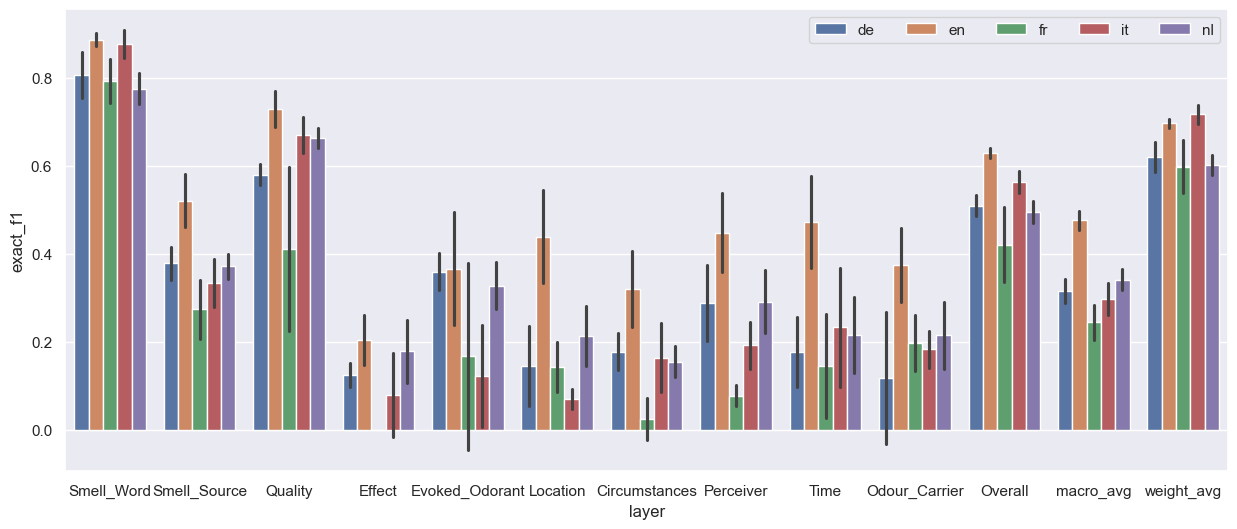

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
ax = sns.barplot(folds_score, y='exact_f1', x='ent_type', hue='lang', errorbar='sd')
plt.legend(ncol=len(languages))
ax.figure.set_size_inches(15, 6)

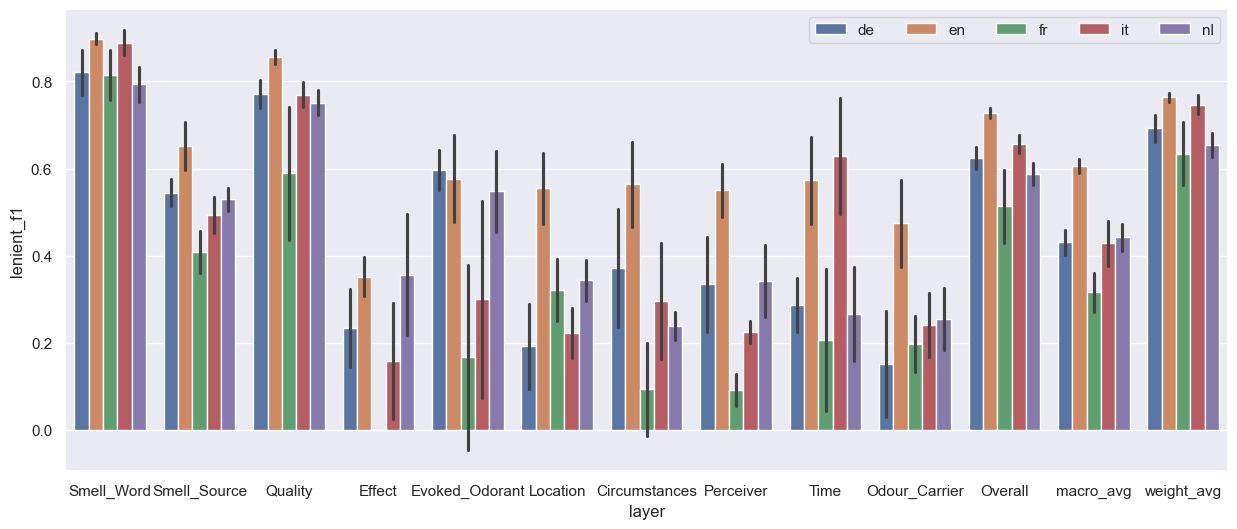

In [29]:
ax = sns.barplot(folds_score, y='lenient_f1', x='ent_type', hue='lang', errorbar='sd')
plt.legend(ncol=len(languages))
ax.figure.set_size_inches(15, 6)